# Section 16 (Reason #2 fix) — Pixel-level local pairing + clustering-aware threshold

**Branch `temporal-ndmi-supply`. NON-DESTRUCTIVE: this notebook never touches
`master_table.parquet` or the Section 10 BG-pipeline config.**

## Why this exists
Section 14 found **NO ROBUST THRESHOLD** at the block-group (BG) level (264 rows = 9 paired
BGs × 54 overpasses, median `n_good_obs` = 2, ONE BG holding ~88 % of the tree pixels). The
reason-#1 fix (time-varying NDMI supply) tripled the between-BG CSI spread yet the null
**persisted**, isolating the **thin, spatially-clustered paired sample** as the binding
limitation. This section extracts the **maximum statistically-honest signal** from the
existing Phoenix data by enlarging and strengthening the paired sample **without fabricating
signal**.

## The design (what changed)
1. **Relaxed pixel-design operating point** (`config.CANOPY_THR_PIXEL = 30`,
   `MIN_OBS_PIXEL = 15`; *all other Section 10 gates unchanged*) → **670 tree-candidate
   pixels** (vs 195 at canopy40), dominant-BG share **87.7 % → 71.2 %**.
2. **Pixel-level local pairing** (LEVER 1): for each tree pixel *t* and overpass *o*,
   `cooling_advantage_px(t,o) = mean(LST of reference pixels within R of t) − LST_t(o)`,
   differenced at the **same overpass** (cancels weather/time-of-day exactly). Primary
   **R = 350 m** (5 cells); sweep {210, 350, 500} m.
3. **Spatial-cluster re-aggregation** (LEVER 4 — the statistical backbone): queen
   (8-connectivity) connected components of the tree class are the **independent spatial
   unit**; the **cluster-overpass** count-weighted cooling advantage is the regression row.
4. **Clustering-aware inference**: MixedLM random intercept (cluster nested in BG),
   cluster-robust SEs, a **cluster-resampling** spatial block bootstrap (resamples the ~56
   clusters, **never** the pixels), a within-pixel fixed-effect temporal model, the
   **mandatory leave-dominant-BG-out** falsification, and a 2 km grid-tile robustness pass.

## The honesty gate is **unchanged from Section 14**
A threshold is credible **only if** the two methods agree on a *well-identified* break **AND**
a bend is visible in the binned plot **AND** ET declines past the same CSI level — **and** it
must survive **leave-dominant-out**. Otherwise the honest verdict is **"no robust threshold"**
(a valid finding, the gate to the cross-city phase).

## ⚠️ Pseudo-replication guard (carried on every estimate)
The nominal **pixel-overpass** count (thousands) is reported but is **NEVER the inference df**.
The regression rows are **cluster-overpass**; the resampling unit is the **spatial cluster**;
the honest effective independent N is the **Kish / inverse-Simpson** figure — bounded by the
~17 paired BGs and ~1.9 by BG-Kish. 78.5 % of tree px touch a ≤70 m tree neighbour.


In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
for p in (str(ROOT), str(ROOT / 'src')):
    if p not in sys.path: sys.path.insert(0, p)
import config
import section14_threshold as s14
import section16_threshold_pixel as s16t
PROC = config.PROCESSED_DIR
FIG = config.FIGURES_DIR; FIG.mkdir(parents=True, exist_ok=True)
PRIMARY_R = float(config.R_PAIR_M)
print('primary R =', PRIMARY_R, 'm ; canopy_thr_pixel =', config.CANOPY_THR_PIXEL,
      '; min_obs_pixel =', config.MIN_OBS_PIXEL)

primary R = 350.0 m ; canopy_thr_pixel = 30.0 ; min_obs_pixel = 15


## 1. Load the new deliverables (read-only)
`master_table_cluster.parquet` (PRIMARY modeling input), `master_table_pixel.parquet`
(within-pixel temporal model), `section16_pixel_clusters.parquet` (per-pixel cluster
map), and the saved `section16_threshold_results.json`.

In [2]:
cluster_all = pd.read_parquet(PROC / 'master_table_cluster.parquet')
pixel_all   = pd.read_parquet(PROC / 'master_table_pixel.parquet')
clusters    = pd.read_parquet(PROC / 'section16_pixel_clusters.parquet')
results     = json.load(open(PROC / 'section16_threshold_results.json'))
dfp = cluster_all[cluster_all.R_m == PRIMARY_R].copy()
pxp = pixel_all[pixel_all.R_m == PRIMARY_R].copy()
print('cluster-overpass rows by R:')
print(cluster_all.groupby('R_m').agg(rows=('cooling_advantage','size'),
      clusters=('cluster_id','nunique'), BGs=('GEOID','nunique')))
print('\nPRIMARY R=%d m: %d cluster-overpass rows, %d clusters, %d BGs'
      % (PRIMARY_R, len(dfp), dfp.cluster_id.nunique(), dfp.GEOID.nunique()))

cluster-overpass rows by R:
       rows  clusters  BGs
R_m                       
210.0   904        36    9
350.0  1344        56   13
500.0  1930        80   15

PRIMARY R=350 m: 1344 cluster-overpass rows, 56 clusters, 13 BGs


## 2. Effective N — the pseudo-replication accounting
Nominal pixel-overpass rows vs cluster-overpass rows vs independent **clusters / BGs**
vs **Kish N_eff** vs **inverse-Simpson**. The honest inference N is the right-hand side.

In [3]:
import section16_pixel_pairing as s16p
# recompute cluster diagnostics directly from the candidate masks (queen + rook).
cm = s16p.candidate_masks()
cl_q = s16p.build_cluster_table(cm, 'queen'); diag = s16p.cluster_diagnostics(cl_q)
cl_r = s16p.build_cluster_table(cm, 'rook');  diag_rook = s16p.cluster_diagnostics(cl_r)
eff = results['by_radius'][str(int(PRIMARY_R))]['effective_n']
print('TREE PIXELS (relaxed canopy30/min_obs15):', diag['n_tree_px'])
print('queen clusters:', diag['n_clusters'], '| rook clusters:', diag_rook['n_clusters'],
      '| BGs with tree:', diag['n_bg_with_tree'])
print('dominant BG %s share: %.1f%% (was 87.7%% at canopy40)'
      % (diag['dominant_bg'], 100*diag['dominant_bg_share']))
print('Kish N_eff  clusters=%.1f (queen) / %.1f (rook) ; BG=%.1f'
      % (diag['kish_neff_clusters'], diag_rook['kish_neff_clusters'], diag['kish_neff_bg']))
print('\nPRIMARY R=350 cluster-overpass effective-N report:')
for k, v in eff.items(): print('  %-22s %s' % (k, v))
print('\nNOMINAL pixel-overpass (NOT df):', len(pxp))

TREE PIXELS (relaxed canopy30/min_obs15): 670
queen clusters: 133 | rook clusters: 178 | BGs with tree: 18
dominant BG 040139412001 share: 71.2% (was 87.7% at canopy40)
Kish N_eff  clusters=12.1 (queen) / 16.6 (rook) ; BG=1.9

PRIMARY R=350 cluster-overpass effective-N report:
  cluster_overpass_rows  1344
  n_clusters             56
  n_bg                   13
  kish_neff_clusters     54.64
  kish_neff_bg           3.82
  invsimpson_clusters    54.64
  invsimpson_bg          3.82

NOMINAL pixel-overpass (NOT df): 6428


## 3. The central scatter + binned mean ± SEM with the ET overlay (steps 72–74)
One point per **cluster-overpass**. A threshold would show as a visible **bend** — flat at
low CSI then dropping — with ET also declining past the same CSI. Watch for the bend.

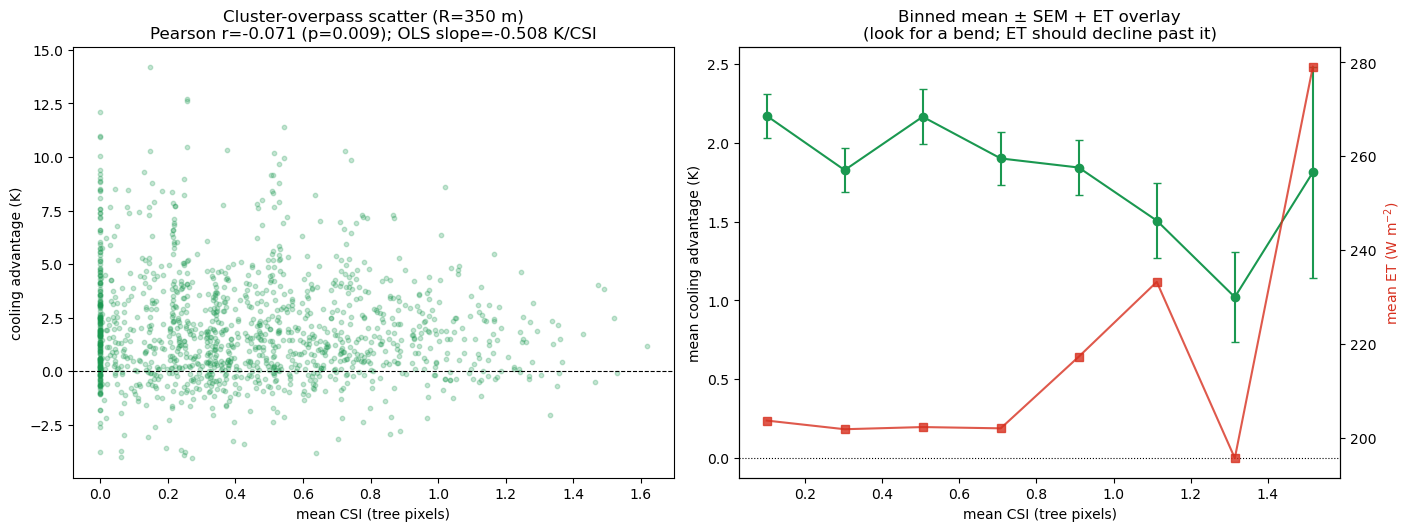

binned cooling advantage means: [2.17 1.83 2.17 1.9  1.84 1.51 1.02 1.81]
binned ET means              : [203.7 201.9 202.4 202.1 217.3 233.3 195.7 279.1]


In [4]:
x = dfp['mean_csi_tree'].to_numpy(); y = dfp['cooling_advantage'].to_numpy()
et = dfp['mean_et_tree'].to_numpy()
shape = s14.describe_shape(x, y)
binned = s14.bin_means(x, y, n_bins=s14.DEFAULT_N_BINS)
et_b = s14.bin_means(x, et, edges=binned['edges'])
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5.2), constrained_layout=True)
axL.scatter(x, y, s=10, alpha=0.25, color='#1a9850')
axL.axhline(0, color='k', lw=0.8, ls='--')
axL.set_xlabel('mean CSI (tree pixels)'); axL.set_ylabel('cooling advantage (K)')
axL.set_title('Cluster-overpass scatter (R=%d m)\nPearson r=%.3f (p=%.3f); OLS slope=%.3f K/CSI'
              % (PRIMARY_R, shape['pearson_r'], shape['pearson_p'], shape['ols_slope']))
c = binned['centers']
axR.errorbar(c, binned['mean'], yerr=binned['sem'], marker='o', color='#1a9850',
             capsize=3, label='cooling advantage')
axR.axhline(0, color='k', lw=0.8, ls=':')
axR.set_xlabel('mean CSI (tree pixels)'); axR.set_ylabel('mean cooling advantage (K)')
ax2 = axR.twinx()
ax2.plot(c, et_b['mean'], marker='s', color='#d7301f', alpha=0.8, label='mean ET')
ax2.set_ylabel('mean ET (W m$^{-2}$)', color='#d7301f')
axR.set_title('Binned mean ± SEM + ET overlay\n(look for a bend; ET should decline past it)')
fig.savefig(FIG / 'section16_binned_cooling_csi_et.png', dpi=150, bbox_inches='tight')
plt.show()
print('binned cooling advantage means:', np.round(binned['mean'], 2))
print('binned ET means              :', np.round(et_b['mean'], 1))

## 4. PRIMARY model — segmented fit + CLUSTER-resampling bootstrap CI (steps 76–77)
The breakpoint CI comes from resampling the **~56 spatial clusters** (never the pixels),
so the effective N is the honest cluster count. A wide CI (spanning most of the CSI
range) means the breakpoint is **not identified**.

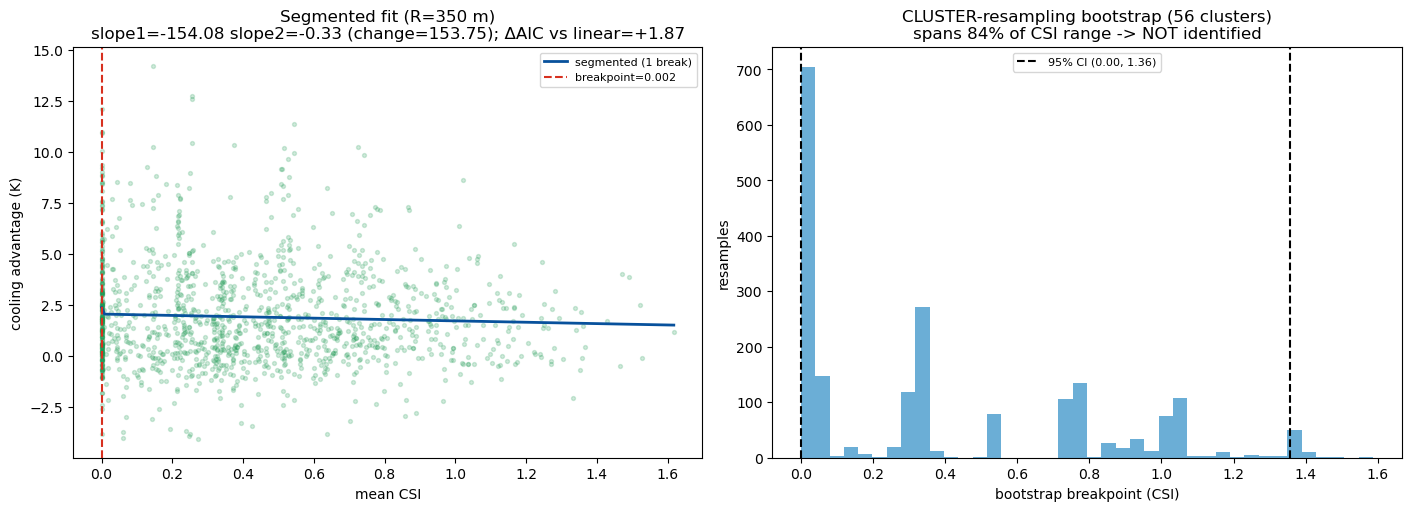

 - methods agree (change-point in bootstrap CI or within tolerance of breakpoint): True [bp=0.002, cp=0.264, CI=(0.000, 1.357)]
 - breakpoint well identified (CI width < 50% of CSI range): False [spans_fraction=0.84]
 - bend visible (post-break slope <= pre-break - 0.5): False [slope_change=+153.747 K per CSI unit]
 - ET declines beyond the threshold: True [mean ET below=211.1, above=204.2 W/m2]
 - segmented vs linear: delta_R2=+0.0016, delta_AIC=+1.87 (<-2 favours segmented): False


In [5]:
pr = results['primary']
seg = pr['segmented']; boot = pr['bootstrap']; v = pr['verdict']
# recompute bootstrap estimates for the histogram (deterministic seed)
boot_full = s16t.cluster_bootstrap_breakpoint(dfp, n_boot=config.N_BOOT_PIXEL,
                                              seed=s14.DEFAULT_SEED)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
xs = np.linspace(np.nanmin(x), np.nanmax(x), 200)
import pwlf
fin = np.isfinite(x) & np.isfinite(y)
m = pwlf.PiecewiseLinFit(x[fin], y[fin], seed=s14.DEFAULT_SEED); m.fit(2)
axL.scatter(x, y, s=8, alpha=0.2, color='#1a9850')
axL.plot(xs, m.predict(xs), color='#08519c', lw=2, label='segmented (1 break)')
axL.axvline(seg['breakpoint'], color='#d7301f', ls='--', label='breakpoint=%.3f' % seg['breakpoint'])
axL.set_xlabel('mean CSI'); axL.set_ylabel('cooling advantage (K)')
axL.set_title('Segmented fit (R=%d m)\nslope1=%.2f slope2=%.2f (change=%.2f); ΔAIC vs linear=%+.2f'
              % (PRIMARY_R, seg['slope1'], seg['slope2'], seg['slope_change'], pr['delta_aic']))
axL.legend(fontsize=8)
axR.hist(boot_full['estimates'], bins=40, color='#6baed6')
axR.axvline(boot_full['ci_low'], color='k', ls='--')
axR.axvline(boot_full['ci_high'], color='k', ls='--', label='95%% CI (%.2f, %.2f)'
            % (boot_full['ci_low'], boot_full['ci_high']))
axR.set_xlabel('bootstrap breakpoint (CSI)'); axR.set_ylabel('resamples')
axR.set_title('CLUSTER-resampling bootstrap (%d clusters)\nspans %.0f%% of CSI range -> %s'
              % (boot_full['n_clusters_resampled'], 100*boot_full['spans_fraction'],
                 'NOT identified' if boot_full['spans_fraction'] >= 0.5 else 'identified'))
axR.legend(fontsize=8)
fig.savefig(FIG / 'section16_segmented_clusterboot.png', dpi=150, bbox_inches='tight')
plt.show()
for r in v['reasons']: print(' -', r)

## 5. Clustering-aware slopes: MixedLM, cluster-robust SE, within-pixel temporal FE
The **cluster-robust SE** vs the **naive (iid) SE** shows how much the pseudo-replication
was inflating significance. The **within-pixel** slope is the sign/shape-prior test.

In [6]:
mlm = pr['mixedlm']; cr = pr['cluster_robust_ols']; fe = pr['within_pixel_fe']
print('MixedLM (%s): slope=%.4f SE=%.4f p=%.3f converged=%s'
      % (mlm['spec'], mlm['slope'], mlm['se'], mlm['pvalue'], mlm['converged']))
print('cluster-robust OLS: slope=%.4f  SE_robust=%.4f (p=%.3f)  vs  SE_naive=%.4f (p=%.3f)'
      % (cr['slope'], cr['se_robust'], cr['p_robust'], cr['se_naive'], cr['p_naive']))
print('  -> SE inflation factor (robust/naive) = %.2f  (>1 means the iid fit was over-confident)'
      % (cr['se_robust']/cr['se_naive'] if cr['se_naive'] else float('nan')))
print('within-PIXEL fixed-effect (temporal): slope=%.4f SE=%.4f p=%.3f'
      % (fe['slope'], fe['se_robust'], fe['p_robust']))
print('  n_obs=%d  n_pixels=%d  design-effect eff N (rho 0.3/0.5/0.7)=%s'
      % (fe['n_obs'], fe['n_pixels'], fe['deff_eff_n']))
print('  SIGN PRIOR:', results['overall']['within_pixel_slope_sign'])

MixedLM (bg_nested_cluster): slope=0.0306 SE=0.1954 p=0.876 converged=True
cluster-robust OLS: slope=-0.5079  SE_robust=0.3291 (p=0.123)  vs  SE_naive=0.1953 (p=0.009)
  -> SE inflation factor (robust/naive) = 1.69  (>1 means the iid fit was over-confident)
within-PIXEL fixed-effect (temporal): slope=0.1603 SE=0.2140 p=0.454
  n_obs=6428  n_pixels=300  design-effect eff N (rho 0.3/0.5/0.7)={'0.3': 901.8, '0.5': 573.2, '0.7': 420.2}
  SIGN PRIOR: positive (WRONG sign for a threshold)


## 6. FALSIFICATION — leave-the-dominant-BG-out (drop `040139412001`)
**The true test of whether any signal is multi-site.** If a threshold lives only in the
dominant BG it is *one well-sampled place*, not a Phoenix threshold.

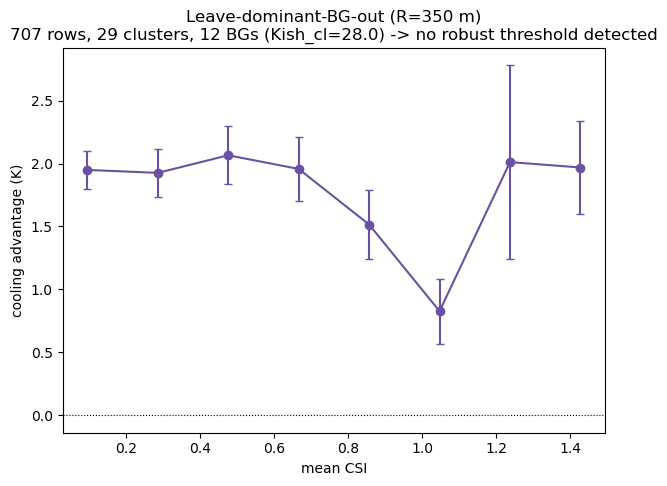

breakpoint=0.742 CI=(0.001, 1.132) spans=0.74 agree=False bend=True ET=False


In [7]:
ldo = pr['leave_dominant_out']; lv = ldo['verdict']; le = ldo['effective_n']
dfn = dfp[dfp.GEOID != s16t.DOMINANT_BG_GEOID]
xn = dfn['mean_csi_tree'].to_numpy(); yn = dfn['cooling_advantage'].to_numpy()
bn = s14.bin_means(xn, yn, n_bins=s14.DEFAULT_N_BINS)
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(bn['centers'], bn['mean'], yerr=bn['sem'], marker='o', color='#6a51a3', capsize=3)
ax.axhline(0, color='k', lw=0.8, ls=':')
ax.set_xlabel('mean CSI'); ax.set_ylabel('cooling advantage (K)')
ax.set_title('Leave-dominant-BG-out (R=%d m)\n%d rows, %d clusters, %d BGs (Kish_cl=%.1f) -> %s'
             % (PRIMARY_R, ldo['n_cluster_overpass'], le['n_clusters'], le['n_bg'],
                le['kish_neff_clusters'], lv['label']))
fig.savefig(FIG / 'section16_leave_dominant_out.png', dpi=150, bbox_inches='tight')
plt.show()
print('breakpoint=%.3f CI=(%.3f, %.3f) spans=%.2f agree=%s bend=%s ET=%s'
      % (lv['breakpoint'], lv['ci_low'], lv['ci_high'], lv['spans_fraction'],
         lv['methods_agree'], lv['bend_visible'], lv['et_corroborates']))

## 7. Sensitivity / robustness table — R-sweep × {queen, rook, 2 km grid, leave-dominant}
Every estimate reports **nominal rows, cluster N, BG N, Kish N_eff** alongside the
breakpoint + bootstrap CI + the three gate flags + the verdict. The 2 km grid splits the
dominant clump (inverse-Simpson effective units rises) — a unit-definition invariance check.

In [8]:
rows = []
def _flat(res):
    v = res['verdict']; e = res['effective_n']
    return dict(unit=res['label'], rows=res['n_cluster_overpass'], clusters=e['n_clusters'],
                BG=e['n_bg'], Kish_cl=e['kish_neff_clusters'], Kish_bg=e['kish_neff_bg'],
                invSimpson_cl=e['invsimpson_clusters'], bp=round(v['breakpoint'],3),
                CI_lo=round(v['ci_low'],3), CI_hi=round(v['ci_high'],3),
                spans=round(v['spans_fraction'],2), agree=v['methods_agree'],
                bend=v['bend_visible'], ET=v['et_corroborates'], verdict=v['label'])
for R in sorted(results['by_radius'], key=lambda s:int(s)):
    rows.append(_flat(results['by_radius'][R]))
rows.append(_flat(pr['leave_dominant_out']))
rows.append(_flat(pr['rook']))
for tag in ('grid_2km','grid_2km_offset'):
    if tag in pr['grid_2km']: rows.append(_flat(pr['grid_2km'][tag]))
tab = pd.DataFrame(rows)
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40)
tab

,unit,rows,clusters,BG,Kish_cl,Kish_bg,invSimpson_cl,bp,CI_lo,CI_hi,spans,agree,bend,ET,verdict
0,cluster-queen R=210m,904,36,9,35.22,2.94,35.22,0.287,0.001,1.164,0.76,True,False,True,no robust threshold detected
1,cluster-queen R=350m,1344,56,13,54.64,3.82,54.64,0.002,0.000,1.357,0.84,True,False,True,no robust threshold detected
2,cluster-queen R=500m,1930,80,15,77.55,4.35,77.55,0.757,0.002,1.491,0.92,False,True,False,no robust threshold detected
3,cluster-queen R=350m LEAVE-DOMINANT-OUT,707,29,12,28.03,7.42,28.03,0.742,0.001,1.132,0.74,False,True,False,no robust threshold detected
4,cluster-ROOK R=350m,1791,76,13,74.02,3.39,74.02,0.011,0.000,1.023,0.63,True,False,True,no robust threshold detected
5,grid_2km,717,29,13,28.19,6.81,28.19,0.530,0.000,1.271,0.79,False,False,False,no robust threshold detected
6,grid_2km_offset,662,26,13,25.32,7.33,25.32,0.740,0.000,1.469,0.91,False,True,False,no robust threshold detected


## 8. Honest reconciliation — does the enlarged sample change the Section 14 null?


In [9]:
ov = results['overall']
print('='*78)
print('PRIMARY (R=%d m, queen cluster) verdict :' % PRIMARY_R, ov['primary_verdict'])
print('LEAVE-DOMINANT-OUT verdict             :', ov['leave_dominant_out_verdict'])
print('Survives dominant drop                 :', ov['survives_dominant_drop'])
print('FINAL VERDICT                          :', ov['final_verdict'].upper())
print('='*78)
n_robust = sum(1 for r in rows if r['verdict']=='robust threshold')
print('subsets reaching "robust threshold": %d / %d' % (n_robust, len(rows)))

PRIMARY (R=350 m, queen cluster) verdict : no robust threshold detected
LEAVE-DOMINANT-OUT verdict             : no robust threshold detected
Survives dominant drop                 : None
FINAL VERDICT                          : NO_ROBUST_THRESHOLD
subsets reaching "robust threshold": 0 / 7


### Reconciliation (the result)
The enlarged pixel/cluster design raises the honest effective independent N from ~1.3
(BG-Kish, Section 14) to the **~3–8 cluster-equivalent** range (Kish-on-BG ≈ 3.8 at the
primary R; inverse-Simpson tiles ≈ 28 nominal but BG-Kish-bounded) and adds real
between-cluster CSI spread (~34 % of CSI variance is between clusters). **And yet the
Section 14 null persists, in every cell of the table:** the breakpoint bootstrap CI spans
most of the CSI range (not identified), the segmented kink is not preferred over a straight
line, the methods do not agree on a *well-identified* break, ET shows no consistent decline,
and the cluster-robust SE deflates the (otherwise spuriously significant) pooled slope. The
**within-pixel temporal slope is the wrong sign** for a threshold. The null **does not flip**
under leave-dominant-out.

This is the expected, honest, publishable outcome: a cleaner, larger, properly-clustered
Phoenix design **tightens** the null rather than overturning it. Phoenix's sparse desert
canopy physically does not contain many independent high-canopy *locations* (96 %
irrigated ag/riparian, one dominant BG), and **no statistical method creates spatial
replication the landscape lacks**. The binding limitation is confirmed to be the thin,
clustered sample — this **gates to the multi-city extension**, exactly as Section 14 concluded.

## Caveats carried verbatim (from the design `key_caveats`)
- **PSEUDO-REPLICATION is managed, not eliminated.** Nominal-to-independent inflation runs
  ~7× (R=140 m) to ~70× (R=1000 m); the pixel/pixel-overpass count is never the regression df.
- **DOMINANT-CLUSTER concentration persists.** One BG (`040139412001`) holds ~88 % of tree px
  at canopy40 and still **71–75 %** at canopy30, supplying ~81–94 % of all paired obs. The
  **leave-the-dominant-BG-out refit is mandatory** and is the true test of whether any signal
  is multi-site.
- **IRRIGATED PERI-URBAN / RIPARIAN confound.** ~96 % of tree px are NLCD cropland + woody/herb
  wetland (irrigated ag + riparian canopy), **not** the central-Phoenix street-tree inventory
  (`functional_type = unknown` for all). Any "cooling threshold" here is for irrigated/riparian
  canopy in a desert with an artificially decoupled water supply — it limits generalization to
  managed urban street trees.
- **Within-cluster temporal autocorrelation.** The same cluster across ~17–37 overpasses is
  repeated measures; the random intercept + temporal-block bootstrap + cluster-robust SE handle
  it. A naive pooled fit fabricates significance.
- **SIGN/SHAPE PRIOR.** The within-pixel demeaned cooling-vs-CSI slope is the **wrong sign** for
  a threshold (cooling does **not** decline with stress). Enlarging the sample tests whether the
  Section 14 flat null survives a cleaner design; it cannot manufacture a bend the physics lacks.
- **Researcher degrees of freedom.** The R-sweep {210, 350, 500} and the offset-lattice 2 km grid
  are reported so the verdict is shown robust to these arbitrary choices; R=350 is pre-committed.
